In [1]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
data = pd.read_csv("../build/Track_Data/output_data.csv")

In [3]:
data

,xx,yy,zz,time,numbeam,id,particle,En,Ek
0,105.587,0.942049,-0.344924,1.0,1,0,1,99972.100000,99964.900000
1,104.740,-0.366638,1.772140,1.0,1,1,1,33.964800,26.672800
2,106.443,0.366638,-1.772140,1.0,1,2,0,-1.183680,1.183680
3,210.277,8.746880,-0.597174,2.0,1,0,1,98697.500000,98690.200000
4,106.046,-1.442790,2.833400,2.0,1,1,1,19.634000,12.342000
...,...,...,...,...,...,...,...,...,...
21133753,4483.770,1390.520000,765.712000,12962.0,1,1706,0,-0.018108,0.018108
21133754,4483.760,1390.530000,765.728000,12963.0,1,1706,0,-0.018108,0.018108
21133755,4483.740,1390.550000,765.743000,12964.0,1,1706,0,-0.018108,0.018108
21133756,4483.730,1390.540000,765.731000,12965.0,1,1706,0,-0.010950,0.010950


In [3]:
k = 3
result = []
time = []
numelectrons = []
numholes = []

time_data = np.sort(data[data['particle'] == 1]['time'].unique())

for i in range(0, len(time_data), 10):
    l = i if i == 0 else i - 1
    subset = data[data['time'] == time_data[l]]
    time.append(time_data[l])

    holes = subset[subset['particle'] == 0][['xx', 'yy', 'zz']].to_numpy()
    electrons = subset[subset['particle'] == 1][['xx', 'yy', 'zz']].to_numpy()

    numelectrons.append(len(electrons))
    numholes.append(len(holes))

    if len(holes) > 0 and len(electrons) > 0:
        tree = cKDTree(holes)
        distances, indices = tree.query(electrons, k=min(k, len(holes))) 

        if distances.ndim == 1:
            distances = distances[:, np.newaxis]

        sum_r = np.sum(distances, axis=1)
        inv_mean_r3 = (k / sum_r)**3 * 10**21

        result.append(inv_mean_r3)

In [ ]:
with open('numelectrons.txt', 'w') as file:
    for i in range(len(time)):
        file.write(str(time[i]))
        file.write("\t" + str(numelectrons[i]))
        file.write("\n")

with open('numholes.txt', 'w') as file:
    for i in range(len(time)):
        file.write(str(time[i]))
        file.write("\t" + str(numholes[i]))
        file.write("\n")

In [5]:
with open('counts.txt', 'w') as file:
    for i in range(len(time)):
        file.write(str(time[i]))
        for n in range(len(result[i])):
            file.write("\t" + str(result[i][n]))
        file.write("\n")

In [4]:
holes = data[data['particle'] == 0].copy()
hole_idx_max = holes.groupby('id')['time'].idxmax()
hr = holes.loc[hole_idx_max][['xx', 'yy', 'zz']].to_numpy()

electrons = data[data['particle'] == 1].copy()
electron_idx_max = electrons.groupby('id')['time'].idxmax()
er = electrons.loc[electron_idx_max][['xx', 'yy', 'zz']].to_numpy()

In [7]:
with open('last_hole_coordinates.csv', 'w') as file:
    file.write("x,y,z\n")
    for i in range(len(hr)):
        file.write(str(hr[i][0]) + "," + str(hr[i][1]) + "," + str(hr[i][2]) + "\n")

with open('last_electron_coordinates.csv', 'w') as file:
    file.write("x,y,z\n")
    for i in range(len(er)):
        file.write(str(er[i][0]) + "," + str(er[i][1]) + "," + str(er[i][2]) + "\n")

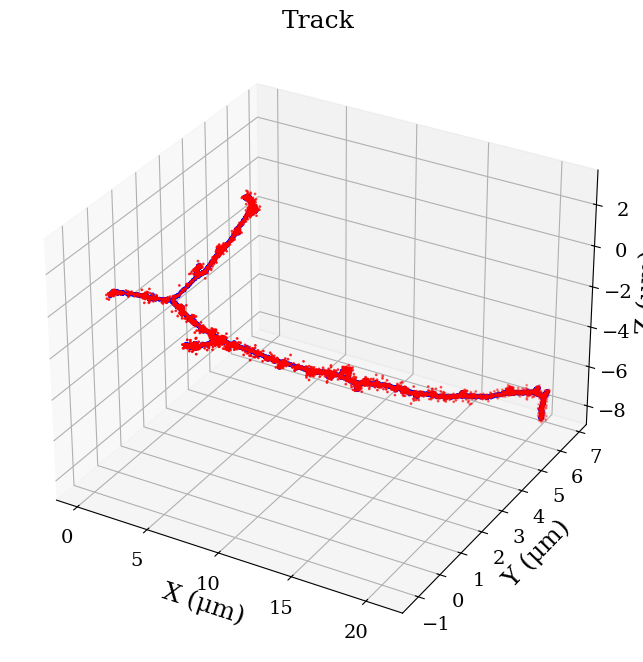

In [5]:
hx = [p[0] * 1e-3 for p in hr]
hy = [p[1] * 1e-3 for p in hr]
hz = [p[2] * 1e-3 for p in hr]

ex = [p[0] * 1e-3 for p in er]
ey = [p[1] * 1e-3 for p in er]
ez = [p[2] * 1e-3 for p in er]

with plt.rc_context({
    'font.family': 'serif',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'serif',
    'mathtext.it': 'serif:italic',
}):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(ex, ey, ez, c='red', marker='o', s=1)
    ax.scatter(hx, hy, hz, c='blue', marker='o', s=5)
    ax.set_xlabel(r'X ($\mathrm{\mu m}$)', fontsize=18)
    ax.set_ylabel(r'Y ($\mathrm{\mu m}$)', fontsize=18)
    ax.set_zlabel(r'Z ($\mathrm{\mu m}$)', fontsize=18)
    ax.set_title('Track', fontsize=18)
    plt.tick_params(axis='both', 
                    which='major', 
                    labelsize=14)
    plt.show()

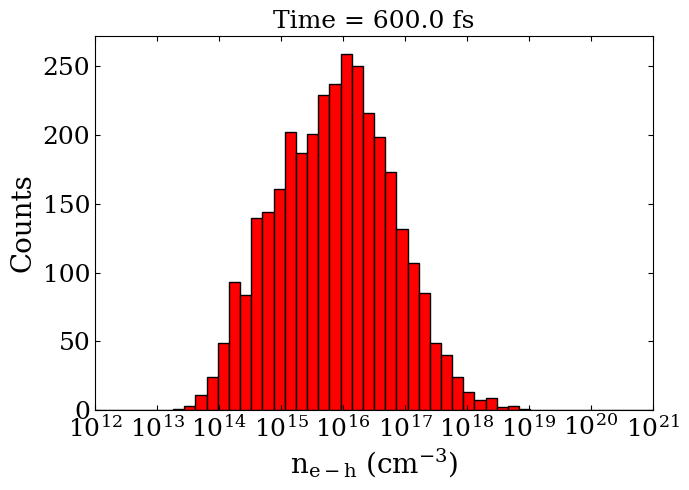

In [6]:
i = 60

bins_log = np.logspace(12, 21, 51)
with plt.rc_context({
    'font.family': 'serif',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'serif',
    'mathtext.it': 'serif:italic',
}):
    plt.figure(figsize=(7, 5))
    plt.hist(result[i], bins=bins_log, edgecolor='black', alpha=1, color="red")
    plt.xlabel(r'$\mathrm{n}_{\mathrm{e-h}}$ ($\mathrm{cm}^{\mathrm{-3}}$)', fontsize=20)
    plt.ylabel('Counts', fontsize=20)
    plt.title(f'Time = {time[i]} fs', fontsize=18)
    plt.tick_params(axis='both', 
                    which='major', 
                    labelsize=18,
                    top=True,
                    bottom=True,
                    left=True,
                    right=True,
                    direction='in')
    plt.xscale('log')
    #plt.yscale('log')
    plt.xlim([1e12, 1e21])
    plt.xticks([1e12, 1e13, 1e14, 1e15, 1e16, 1e17, 1e18, 1e19, 1e20, 1e21]) 
    plt.tight_layout()
    plt.show()

In [7]:
time_unique = [10.0, 30.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0, 120.0, 150.0, 200.0, 300.0, 350.0, 400.0, 450.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 850.0, 900.0, 950.0, 1000.0, 1100.0, 1200.0, 1300.0, 1400.0, 1500.0, 1700.0, 2000.0, 2200.0, 2500.0, 2700.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0]
target = pd.DataFrame({'time': time_unique})

data_ex = data[data['particle'] == 2].sort_values('time').reset_index(drop=True)

numeric_cols = ['xx', 'yy', 'zz', 'En', 'Ek']

interp_rows = []

for (nb, pid), group in data_ex.groupby(['numbeam', 'id']):
    group = group.sort_values('time')
    
    rename_left = {'time': 'time_l'}
    rename_left.update({col: col + '_l' for col in numeric_cols})
    group_left = group.rename(columns=rename_left)
    
    rename_right = {'time': 'time_r'}
    rename_right.update({col: col + '_r' for col in numeric_cols})
    group_right = group.rename(columns=rename_right)
    
    left = pd.merge_asof(target, group_left,
                         left_on='time', right_on='time_l',
                         direction='backward')
    right = pd.merge_asof(target, group_right,
                          left_on='time', right_on='time_r',
                          direction='forward')
    
    interp = left.copy()
    interp['time_r'] = right['time_r']
    for col in numeric_cols:
        interp[col + '_r'] = right[col + '_r']
    
    interp['has_both'] = interp['time_l'].notna() & interp['time_r'].notna()
    dt = interp['time_r'] - interp['time_l']
    alpha = np.where((interp['has_both']) & (dt > 0),
                     (interp['time'] - interp['time_l']) / dt, 0.0)
    
    for idx, row in interp.iterrows():
        if not row['has_both']:
            continue
        
        new_row = {
            'time': row['time'],
            'particle': 2,
            'numbeam': nb,
            'id': pid
        }
        
        a = alpha[idx]
        for col in numeric_cols:
            val = row[col + '_l'] * (1 - a) + row[col + '_r'] * a
            new_row[col] = val
        
        interp_rows.append(new_row)

new_data_ex = pd.DataFrame(interp_rows)

data_eh = data[(data['particle'].isin([0, 1])) & (data['time'].isin(time_unique))]
new_data = pd.concat([data_eh, new_data_ex], ignore_index=True)

In [8]:
k = 3
result2 = []
numexcitons = []

for t in time_unique:
    subset = new_data[new_data['time'] == t]

    electrons = subset[subset['particle'] == 1][['xx', 'yy', 'zz']].to_numpy()
    excitons = subset[subset['particle'] == 2][['xx', 'yy', 'zz']].to_numpy()
    numexcitons.append(len(excitons))

    if len(excitons) > 0 and len(electrons) > 0:
        tree = cKDTree(electrons)
        distances, indices = tree.query(excitons, k=min(k, len(electrons))) 

        if distances.ndim == 1:
            distances = distances[:, np.newaxis]

        sum_r = np.sum(distances, axis=1)
        inv_mean_r3 = (k / sum_r)**3 * 10**21

        result2.append(inv_mean_r3)

In [36]:
with open('numexcitons.txt', 'w') as file:
    for i in range(len(time_unique)):
        file.write(str(time_unique[i]))
        file.write("\t" + str(numexcitons[i]))
        file.write("\n")


In [ ]:
with open('counts2.txt', 'w') as file:
    for i in range(len(time_unique)):
        file.write(str(time_unique[i]))
        for n in range(len(result2[i])):
            file.write("\t" + str(result2[i][n]))
        file.write("\n")

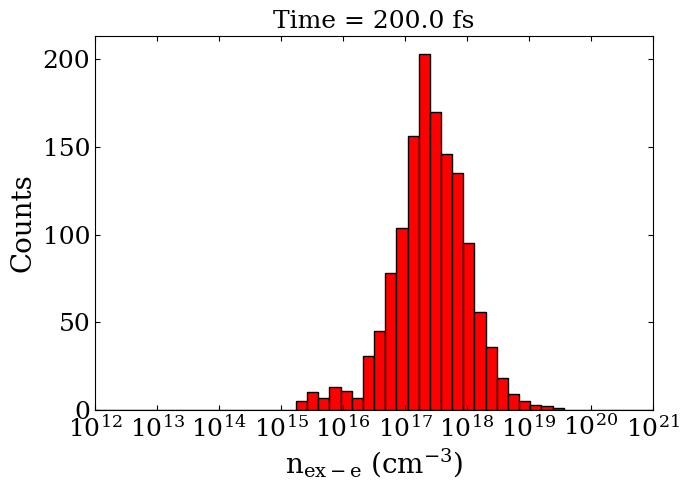

In [9]:
i = 10

bins_log = np.logspace(12, 21, 51)
with plt.rc_context({
    'font.family': 'serif',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'serif',
    'mathtext.it': 'serif:italic',
}):
    plt.figure(figsize=(7, 5))
    plt.hist(result2[i], bins=bins_log, edgecolor='black', alpha=1, color="red")
    plt.xlabel(r'$\mathrm{n}_{\mathrm{ex-e}}$ ($\mathrm{cm}^{\mathrm{-3}}$)', fontsize=20)
    plt.ylabel('Counts', fontsize=20)
    plt.title(f'Time = {time_unique[i]} fs', fontsize=18)
    plt.tick_params(axis='both', 
                    which='major', 
                    labelsize=18,
                    top=True,
                    bottom=True,
                    left=True,
                    right=True,
                    direction='in')
    plt.xscale('log')
    #plt.yscale('log')
    plt.xlim([1e12, 1e21])
    plt.xticks([1e12, 1e13, 1e14, 1e15, 1e16, 1e17, 1e18, 1e19, 1e20, 1e21]) 
    plt.tight_layout()
    plt.show()

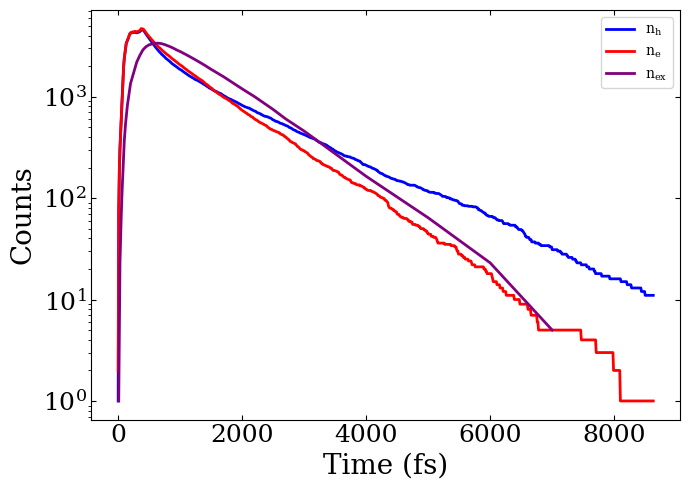

In [10]:
with plt.rc_context({
    'font.family': 'serif',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'serif',
    'mathtext.it': 'serif:italic',
}):
    plt.figure(figsize=(7, 5))
    plt.plot(time, numholes, alpha=1, label=r'$\mathrm{n}_{\mathrm{h}}$', linewidth=2, color='blue')
    plt.plot(time, numelectrons, alpha=1, label=r'$\mathrm{n}_{\mathrm{e}}$', linewidth=2, color='red')
    plt.plot(time_unique, numexcitons, alpha=1, label=r'$\mathrm{n}_{\mathrm{ex}}$', linewidth=2, color='purple')
    plt.xlabel("Time (fs)", fontsize=20)
    plt.ylabel("Counts", fontsize=20)
    plt.tick_params(axis='both', 
                    which='major', 
                    labelsize=18,
                    top=True,
                    bottom=True,
                    left=True,
                    right=True,
                    direction='in')
    plt.legend()
    #plt.xscale('log')
    plt.yscale('log')
    plt.tight_layout()
    plt.show()